In [1]:
import numpy as np
import math
import csv
import numpy as np
import matplotlib.pyplot as plt

###### BASIC compressor
## calculate 1bit mult per each partial sum position
def partial_bit(x, xl, y, yl, loc=0):
    return (((x >> xl) & (y >> yl) & 1) << loc)

## sum of half adder,, &1 is for acquiring 1bit output
def sha(x, y):
    return ((x ^ y) & 1)

## carry out of half adder
def cha(x, y):
    return ((x & y) & 1)

## sum of full adder
def sfa(x, y, z):
    return ((x ^ y ^ z) & 1)

## carry out of full adder,, same as 
def cfa(x, y, z):
    return ((x & y) | (x & z) | (y & z)) & 1

## exact version of 4:2 compressor == 5 to 3 compressor
def exact_4to2_compressor(x1, x2, x3, x4, Tin):
    # pre-process
    Tin = Tin & 1
    x1  = x1  & 1
    x2  = x2  & 1
    x3  = x3  & 1
    x4  = x4  & 1

    # real calc
    Tout = cfa(x4, x3, x2)
    temp = sfa(x4, x3, x2)
    carry_bit = cfa(temp, x1, Tin)
    sum_bit   = sfa(temp, x1, Tin)

    return sum_bit, carry_bit, Tout


###### suggested compressor
def Ahma4to2(a, b, c, d):
    x1 = a & 1
    x2 = b & 1
    x3 = c & 1
    x4 = d & 1

    temp1 = (~(x1 | x2)) & 1
    temp2 = (~(x3 | x4)) & 1

    carry_bit = (~(temp1 | temp2)) & 1
    sum_bit   = (~(temp1 & temp2)) & 1

    return sum_bit, carry_bit

def Ansari4to2(a, b, c, d):
    x1 = a & 1
    x2 = b & 1
    x3 = c & 1
    x4 = d & 1

    carry_bit = (~((~(x1 & x2)) & (~(x3 & x4)))) & 1
    sum_bit   = (~((~(x1 | x2)) & (~(x3 | x4)))) & 1
    
    return sum_bit, carry_bit

In [4]:
def approx_mult_8bit(x, y):
    ### define first partial sum & final output list
    ab = np.zeros((8, 8), dtype=int)
    o  = np.zeros(16, dtype=int)

    ####################################
    ### stage0: generate partial sum ###
    ####################################
    for i in range(8):
        for j in range(8):
            ab[i, j] = partial_bit(x, 7 - i, y, 7 - j, 0)
    """
    RESULT: 
                                                                                  X(8bit)
                                                                                * Y(8bit)
        ---------------------------------------------------------------------------------
                                          [0,7] [1,7] [2,7] [3,7] [4,7] [5,7] [6,7] [7,7] 
                                    [0,6] [1,6] [2,6] [3,6] [4,6] [5,6] [6,6] [7,6]  
                              [0,5] [1,5] [2,5] [3,5] [4,5] [5,5] [6,5] [7,5]  
                        [0,4] [1,4] [2,4] [3,4] [4,4] [5,4] [6,4] [7,4]  
                  [0,3] [1,3] [2,3] [3,3] [4,3] [5,3] [6,3] [7,3]
            [0,2] [1,2] [2,2] [3,2] [4,2] [5,2] [6,2] [7,2]
      [0,1] [1,1] [2,1] [3,1] [4,1] [5,1] [6,1] [7,1]
[0,0] [1,0] [2,0] [3,0] [4,0] [5,0] [6,0] [7,0]

    """

    ###############
    ### Stage 1 ###
    ###############
    c_h0_1s = cha(ab[3,7], ab[4,6])
    s_h0_1s = sha(ab[3,7], ab[4,6])

    c_h1_1s = cha(ab[5,3], ab[6,2])
    s_h1_1s = sha(ab[5,3], ab[6,2])

    c_h2_1s = cha(ab[4,1], ab[5,0])
    s_h2_1s = sha(ab[4,1], ab[5,0])

    c_h3_1s = cha(ab[0,3], ab[1,2])
    s_h3_1s = sha(ab[0,3], ab[1,2])

    c_f0_1s = cfa(ab[4,2], ab[5,1], ab[6,0])
    s_f0_1s = sfa(ab[4,2], ab[5,1], ab[6,0])
    
    s_m0_1s, c_m0_1s = Ahma4to2(ab[2,7], ab[3,6], ab[4,5], ab[5,4])
    s_m1_1s, c_m1_1s = Ahma4to2(ab[1,7], ab[2,6], ab[3,5], ab[4,4])
    s_m2_1s, c_m2_1s = Ahma4to2(ab[0,7], ab[1,6], ab[2,5], ab[3,4])
    s_m3_1s, c_m3_1s = Ahma4to2(ab[4,3], ab[5,2], ab[6,1], ab[7,0])
    s_m4_1s, c_m4_1s = Ahma4to2(ab[0,6], ab[1,5], ab[2,4], ab[3,3])
    s_m5_1s, c_m5_1s = Ahma4to2(ab[0,5], ab[1,4], ab[2,3], ab[3,2])
    s_m6_1s, c_m6_1s = Ahma4to2(ab[0,4], ab[1,3], ab[2,2], ab[3,1])

    
    ###############
    ### Stage 2 ###
    ###############
    c_h4_2s = cha(ab[5,7], ab[6,6])
    s_h4_2s = sha(ab[5,7], ab[6,6])

    c_h5_2s = cha(ab[1,0], ab[0,1])
    s_h5_2s = sha(ab[1,0], ab[0,1])

    s_m7_2s,  c_m7_2s  =   Ahma4to2(ab[4,7], ab[5,6], ab[6,5], ab[7,4])
    s_m8_2s,  c_m8_2s  =   Ahma4to2(ab[5,5], ab[6,4], ab[7,3], s_h0_1s)
    s_m9_2s,  c_m9_2s  = Ansari4to2(ab[6,3], c_h0_1s, ab[7,2], s_m0_1s)
    s_m10_2s, c_m10_2s = Ansari4to2(ab[7,1], c_m0_1s, s_m1_1s, s_h1_1s)
    s_m11_2s, c_m11_2s = Ansari4to2(c_m1_1s, c_h1_1s, s_m2_1s, s_m3_1s)
    s_m12_2s, c_m12_2s = Ansari4to2(c_m2_1s, c_m3_1s, s_m4_1s, s_f0_1s)
    s_m13_2s, c_m13_2s = Ansari4to2(c_m4_1s, c_f0_1s, s_m5_1s, s_h2_1s)
    s_m14_2s, c_m14_2s = Ansari4to2(c_m5_1s, c_h2_1s, ab[4,0], s_m6_1s)
    s_m15_2s, c_m15_2s =   Ahma4to2(ab[2,1], ab[3,0], c_m6_1s, s_h3_1s)
    s_m16_2s, c_m16_2s =   Ahma4to2(ab[0,2], ab[1,1], ab[2,0], c_h3_1s)


    ####################################
    ### Stage 3 (final accumulation) ###
    ####################################
    o[0] = ab[7,7]

    o[1]    = sha(ab[6,7], ab[7,6])
    c_h6_3s = cha(ab[6,7], ab[7,6])

    o[2]    = sfa(ab[7,5], s_h4_2s, c_h6_3s)
    c_f1_3s = cfa(ab[7,5], s_h4_2s, c_h6_3s)

    o[3]    = sfa(s_m7_2s, c_h4_2s, c_f1_3s)
    c_f2_3s = cfa(s_m7_2s, c_h4_2s, c_f1_3s)

    o[4]    = sfa(s_m8_2s, c_m7_2s, c_f2_3s)
    c_f3_3s = cfa(s_m8_2s, c_m7_2s, c_f2_3s)

    o[5]    = sfa(s_m9_2s, c_m8_2s, c_f3_3s)
    c_f4_3s = cfa(s_m9_2s, c_m8_2s, c_f3_3s)

    o[6]    = sfa(s_m10_2s, c_m9_2s, c_f4_3s)
    c_f5_3s = cfa(s_m10_2s, c_m9_2s, c_f4_3s)

    o[7]    = sfa(s_m11_2s, c_m10_2s, c_f5_3s)
    c_f6_3s = cfa(s_m11_2s, c_m10_2s, c_f5_3s)

    o[8]    = sfa(s_m12_2s, c_m11_2s, c_f6_3s)
    c_f7_3s = cfa(s_m12_2s, c_m11_2s, c_f6_3s)

    o[9]    = sfa(s_m13_2s, c_m12_2s, c_f7_3s)
    c_f8_3s = cfa(s_m13_2s, c_m12_2s, c_f7_3s)

    o[10]   = sfa(s_m14_2s, c_m13_2s, c_f8_3s)
    c_f9_3s = cfa(s_m14_2s, c_m13_2s, c_f8_3s)

    o[11]   = sfa(s_m15_2s, c_m14_2s, c_f9_3s)
    c_f10_3s= cfa(s_m15_2s, c_m14_2s, c_f9_3s)

    o[12]   = sfa(s_m16_2s, c_m15_2s, c_f10_3s)
    c_f11_3s= cfa(s_m16_2s, c_m15_2s, c_f10_3s)

    o[13]   = sfa(s_h5_2s,  c_m16_2s, c_f11_3s)
    c_f12_3s= cfa(s_h5_2s,  c_m16_2s, c_f11_3s)

    o[14]   = sfa(ab[0,0],  c_h5_2s,  c_f12_3s)
    o[15]   = cfa(ab[0,0],  c_h5_2s,  c_f12_3s)


    ###################
    ### pack result ###
    ###################
    out = 0
    for i in range(16):
        out |= (o[i] << i)

    return int(out)

In [6]:
k = 8
max_val = 2 ** k  # 256

##############################################
# 1) save a, b (inputs), exact, approx value #
##############################################
csv_filename = "approx_output.csv"
with open(csv_filename, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["A", "B", "Exact", "Approx"])
    for A in range(max_val):
        for B in range(max_val):
            exact = A * B
            out = approx_mult_8bit(A, B)
            writer.writerow([A, B, exact, out])


################################################################
# 2) max error distance(ed), count_correct, sum_rerr, avg_rerr #
################################################################
max_ed = 0
max_A = 0
max_B = 0
count_correct = 0
sum_rerr = 0.0

for A in range(max_val):
    for B in range(max_val):
        exact = A * B
        out = approx_mult_8bit(A, B)

        ed = abs(out - exact)
        if ed == 0:
            count_correct += 1
        if ed > max_ed:
            max_ed = ed
            max_A = A
            max_B = B

        if exact != 0:
            sum_rerr += (out - exact) / float(exact)

total_pairs = float(max_val * max_val)
avg_rerr = sum_rerr / total_pairs ## same as MRERR


####################################
# 3) sum_ed, sum_red, sum_var_rerr #
####################################
sum_ed = 0.0
sum_red = 0.0
sum_var_rerr = 0.0
count_pred2  = 0
count_pred50 = 0

for A in range(max_val):
    for B in range(max_val):
        exact = A * B
        out = approx_mult_8bit(A, B)

        ed = abs(out - exact)
        sum_ed += float(ed)

        if exact != 0:
            red = abs(out - exact) / abs(exact)
            sum_red += red

            rerr = (out - exact) / float(exact)
            sum_var_rerr += (avg_rerr - rerr) ** 2

            if red > 0.02:
                count_pred2 += 1
            if red > 0.5:
                count_pred50 += 1

# denom_nmed = (2 ** (2 * k)) * (max_val * max_val)
denom_nmed = (max_val-1) * (max_val-1) * max_val * max_val
nmed = sum_ed / float(denom_nmed)
mred = sum_red / total_pairs
std_rerr = math.sqrt(sum_var_rerr / (total_pairs - 1.0))

er = ((total_pairs - count_correct) / total_pairs) * 100.0  # Error Rate(%)와 동일

#########
# print #
#########
print("============ Summary ============")
# print("sum ed:", sum_ed)
print(f"max error distance: {max_ed} @ A: {max_A}, B:{max_B}")
print(f"count correct: {count_correct} / total: {total_pairs}")
print("error rate:", er)
print("NMED(normalized mean error distance):", nmed)
print("MRED(mean relative error distance):", mred)
print("MRERR(mean relative error):", avg_rerr)
print(f"PRED2: {count_pred2/float(total_pairs)}, PRED50: {count_pred50/float(total_pairs)}")
# print("SUMMRERR:", sum_rerr)
# print("STDEV of RERR:", std_rerr)



============ Summary ============
max error distance: 9088 @ A: 188, B:168
count correct: 9004 / total: 65536.0
error rate: 86.260986328125
NMED(normalized mean error distance): 0.01822146980728566
MRED(mean relative error distance): 0.08027403980707637
MRERR(mean relative error): 0.010656833727593525
PRED2: 0.6865386962890625, PRED50: 0.0


In [5]:
# x should be activation (always positive), y should be weights (positive or negative)
def naive_approx_mult_8bit_signed(x, y):
    ### define first partial sum & final output list
    ab = np.zeros((8, 8), dtype=int)
    o  = np.zeros(16, dtype=int)

    ####################################
    ### stage0: generate partial sum ###
    ####################################
    x_neg = ((~x) + 1) & 0x1FF   # x의 9bit 2's complement (1bit sign, 8bit data)

    for i in range(8):
        for j in range(8):
            if j == 0:  # sign bit row
                ab[i, j] = partial_bit(x_neg, 7 - i, y, 7 - j, 0)
            else:
                ab[i, j] = partial_bit(x, 7 - i, y, 7 - j, 0)
    msb_ = partial_bit(x_neg, 8, y, 7, 0)

    """
    RESULT: 
                                                                                  X(8bit)
                                                                                * Y(8bit)
        ---------------------------------------------------------------------------------
                                          [0,7] [1,7] [2,7] [3,7] [4,7] [5,7] [6,7] [7,7] 
                                    [0,6] [1,6] [2,6] [3,6] [4,6] [5,6] [6,6] [7,6]  
                              [0,5] [1,5] [2,5] [3,5] [4,5] [5,5] [6,5] [7,5]  
                        [0,4] [1,4] [2,4] [3,4] [4,4] [5,4] [6,4] [7,4]  
                  [0,3] [1,3] [2,3] [3,3] [4,3] [5,3] [6,3] [7,3]
            [0,2] [1,2] [2,2] [3,2] [4,2] [5,2] [6,2] [7,2]
      [0,1] [1,1] [2,1] [3,1] [4,1] [5,1] [6,1] [7,1]
[0,0] [1,0] [2,0] [3,0] [4,0] [5,0] [6,0] [7,0] <- 2's comp of X,, there is a msb_ in front of [0,0]

    """

    ###############
    ### Stage 1 ###
    ###############
    c_h0_1s = cha(ab[3,7], ab[4,6])
    s_h0_1s = sha(ab[3,7], ab[4,6])

    c_h1_1s = cha(ab[5,3], ab[6,2])
    s_h1_1s = sha(ab[5,3], ab[6,2])

    c_h2_1s = cha(ab[4,1], ab[5,0])
    s_h2_1s = sha(ab[4,1], ab[5,0])

    c_h3_1s = cha(ab[0,3], ab[1,2])
    s_h3_1s = sha(ab[0,3], ab[1,2])

    c_f0_1s = cfa(ab[4,2], ab[5,1], ab[6,0])
    s_f0_1s = sfa(ab[4,2], ab[5,1], ab[6,0])
    
    s_m0_1s, c_m0_1s = Ahma4to2(ab[2,7], ab[3,6], ab[4,5], ab[5,4])
    s_m1_1s, c_m1_1s = Ahma4to2(ab[1,7], ab[2,6], ab[3,5], ab[4,4])
    s_m2_1s, c_m2_1s = Ahma4to2(ab[0,7], ab[1,6], ab[2,5], ab[3,4])
    s_m3_1s, c_m3_1s = Ahma4to2(ab[4,3], ab[5,2], ab[6,1], ab[7,0])
    s_m4_1s, c_m4_1s = Ahma4to2(ab[0,6], ab[1,5], ab[2,4], ab[3,3])
    s_m5_1s, c_m5_1s = Ahma4to2(ab[0,5], ab[1,4], ab[2,3], ab[3,2])
    s_m6_1s, c_m6_1s = Ahma4to2(ab[0,4], ab[1,3], ab[2,2], ab[3,1])

    
    ###############
    ### Stage 2 ###
    ###############
    c_h4_2s = cha(ab[5,7], ab[6,6])
    s_h4_2s = sha(ab[5,7], ab[6,6])

    c_h5_2s = cha(ab[1,0], ab[0,1])
    s_h5_2s = sha(ab[1,0], ab[0,1])

    s_m7_2s,  c_m7_2s  =   Ahma4to2(ab[4,7], ab[5,6], ab[6,5], ab[7,4])
    s_m8_2s,  c_m8_2s  =   Ahma4to2(ab[5,5], ab[6,4], ab[7,3], s_h0_1s)
    s_m9_2s,  c_m9_2s  = Ansari4to2(ab[6,3], c_h0_1s, ab[7,2], s_m0_1s)
    s_m10_2s, c_m10_2s = Ansari4to2(ab[7,1], c_m0_1s, s_m1_1s, s_h1_1s)
    s_m11_2s, c_m11_2s = Ansari4to2(c_m1_1s, c_h1_1s, s_m2_1s, s_m3_1s)
    s_m12_2s, c_m12_2s = Ansari4to2(c_m2_1s, c_m3_1s, s_m4_1s, s_f0_1s)
    s_m13_2s, c_m13_2s = Ansari4to2(c_m4_1s, c_f0_1s, s_m5_1s, s_h2_1s)
    s_m14_2s, c_m14_2s = Ansari4to2(c_m5_1s, c_h2_1s, ab[4,0], s_m6_1s)
    s_m15_2s, c_m15_2s =   Ahma4to2(ab[2,1], ab[3,0], c_m6_1s, s_h3_1s)
    s_m16_2s, c_m16_2s =   Ahma4to2(ab[0,2], ab[1,1], ab[2,0], c_h3_1s)


    ####################################
    ### Stage 3 (final accumulation) ###
    ####################################
    o[0] = ab[7,7]

    o[1]    = sha(ab[6,7], ab[7,6])
    c_h6_3s = cha(ab[6,7], ab[7,6])

    o[2]    = sfa(ab[7,5], s_h4_2s, c_h6_3s)
    c_f1_3s = cfa(ab[7,5], s_h4_2s, c_h6_3s)

    o[3]    = sfa(s_m7_2s, c_h4_2s, c_f1_3s)
    c_f2_3s = cfa(s_m7_2s, c_h4_2s, c_f1_3s)

    o[4]    = sfa(s_m8_2s, c_m7_2s, c_f2_3s)
    c_f3_3s = cfa(s_m8_2s, c_m7_2s, c_f2_3s)

    o[5]    = sfa(s_m9_2s, c_m8_2s, c_f3_3s)
    c_f4_3s = cfa(s_m9_2s, c_m8_2s, c_f3_3s)

    o[6]    = sfa(s_m10_2s, c_m9_2s, c_f4_3s)
    c_f5_3s = cfa(s_m10_2s, c_m9_2s, c_f4_3s)

    o[7]    = sfa(s_m11_2s, c_m10_2s, c_f5_3s)
    c_f6_3s = cfa(s_m11_2s, c_m10_2s, c_f5_3s)

    o[8]    = sfa(s_m12_2s, c_m11_2s, c_f6_3s)
    c_f7_3s = cfa(s_m12_2s, c_m11_2s, c_f6_3s)

    o[9]    = sfa(s_m13_2s, c_m12_2s, c_f7_3s)
    c_f8_3s = cfa(s_m13_2s, c_m12_2s, c_f7_3s)

    o[10]   = sfa(s_m14_2s, c_m13_2s, c_f8_3s)
    c_f9_3s = cfa(s_m14_2s, c_m13_2s, c_f8_3s)

    o[11]   = sfa(s_m15_2s, c_m14_2s, c_f9_3s)
    c_f10_3s= cfa(s_m15_2s, c_m14_2s, c_f9_3s)

    o[12]   = sfa(s_m16_2s, c_m15_2s, c_f10_3s)
    c_f11_3s= cfa(s_m16_2s, c_m15_2s, c_f10_3s)

    o[13]   = sfa(s_h5_2s,  c_m16_2s, c_f11_3s)
    c_f12_3s= cfa(s_h5_2s,  c_m16_2s, c_f11_3s)

    o[14]   = sfa(ab[0,0],  c_h5_2s,  c_f12_3s)
    c_f13_3s= cfa(ab[0,0],  c_h5_2s,  c_f12_3s)

    o[15]   = sha(msb_, c_f13_3s)


    ###################
    ### pack result ###
    ###################
    out = 0
    for i in range(15):
        out += (o[i] << i)
    if o[15] == 1:
        out -= (1 << 15)

    return int(out)

In [6]:
k = 8
max_val = 2 ** k  # 256

##############################################
# 1) save a, b (inputs), exact, approx value #
##############################################
csv_filename = "naive_approx_output_signed.csv"
with open(csv_filename, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["A", "B", "Exact", "Approx"])
    for A in range(0, 256):
        for B in range(-128, 128):
            exact = A * B
            out = naive_approx_mult_8bit_signed(A, B)
            writer.writerow([A, B, exact, out])


################################################################
# 2) max error distance(ed), count_correct, sum_rerr, avg_rerr #
################################################################
max_ed = 0
max_A = 0
max_B = 0
count_correct = 0
sum_rerr = 0.0

for A in range(0, 256):
    for B in range(-128, 128):
        exact = A * B
        out = naive_approx_mult_8bit_signed(A, B)

        ed = abs(out - exact)
        if ed == 0:
            count_correct += 1
        if ed > max_ed:
            max_ed = ed
            max_A = A
            max_B = B

        if exact != 0:
            sum_rerr += (out - exact) / float(exact)

total_pairs = float(max_val * max_val)
avg_rerr = sum_rerr / total_pairs ## same as MRERR


####################################
# 3) sum_ed, sum_red, sum_var_rerr #
####################################
sum_ed = 0.0
sum_red = 0.0
sum_var_rerr = 0.0
count_pred2  = 0
count_pred50 = 0

for A in range(0, 256):
    for B in range(-128, 128):
        exact = A * B
        out = naive_approx_mult_8bit_signed(A, B)

        ed = abs(out - exact)
        sum_ed += float(ed)

        if exact != 0:
            red = abs(out - exact) / abs(exact)
            sum_red += red

            # rerr = (out - exact) / float(exact)
            # sum_var_rerr += (avg_rerr - rerr) ** 2

            if red > 0.02:
                count_pred2 += 1
            if red > 0.5:
                count_pred50 += 1

MaxOut = 128 * 255
denom_nmed = MaxOut * total_pairs
nmed = sum_ed / float(denom_nmed)
mred = sum_red / total_pairs
# std_rerr = math.sqrt(sum_var_rerr / (total_pairs - 1.0))

er = ((total_pairs - count_correct) / total_pairs) * 100.0  # Error Rate(%)와 동일

#########
# print #
#########
print("============ Summary ============")
# print("sum ed:", sum_ed)
print(f"max error distance: {max_ed} @ A: {max_A}, B:{max_B}")
print(f"count correct: {count_correct} / total: {total_pairs}")
print("error rate:", er)
print("NMED(normalized mean error distance):", nmed)
print("MRED(mean relative error distance):", mred)
print("MRERR(mean relative error):", avg_rerr)
print(f"PRED2: {count_pred2/float(total_pairs)}, PRED50: {count_pred50/float(total_pairs)}")
# print("SUMMRERR:", sum_rerr)
# print("STDEV of RERR:", std_rerr)



============ Summary ============
max error distance: 9088 @ A: 225, B:-78
count correct: 8359 / total: 65536.0
error rate: 87.24517822265625
NMED(normalized mean error distance): 0.03970942029766008
MRED(mean relative error distance): 0.5524663194471512
MRERR(mean relative error): -0.1389634339950153
PRED2: 0.753570556640625, PRED50: 0.1442718505859375


In [2]:
# x should be activation (always positive,, 0 ~ 255), y should be weights (positive or negative,, -128 ~ 127)
# all input are 8bit
# low bit: use inaccurate 4:2 compressor, high bit: use accurate 4:2 compressor
def proposed_approx_mul(x, y):
    ### define first partial sum & final output list
    ab = np.zeros((8, 8), dtype=int)
    o  = np.zeros(16, dtype=int)

    ####################################
    ### stage0: generate partial sum ###
    ####################################
    x_neg = ((~x) + 1) & 0x1FF   # x's 9bit 2's complement (1bit sign, 8bit data)

    for i in range(8):
        for j in range(8):
            if j == 0:  # sign bit row
                ab[i, j] = partial_bit(x_neg, 7 - i, y, 7 - j, 0)
            else:
                ab[i, j] = partial_bit(x, 7 - i, y, 7 - j, 0)
    msb_ = partial_bit(x_neg, 8, y, 7, 0)

    """
    RESULT: 
                                  |                                                     X(8bit)
                                  |                                                   * Y(8bit)
             ---------------------------------------------------------------------------------
                                  |             [0,7] [1,7] [2,7] [3,7] [4,7] [5,7] [6,7] [7,7] 
                                  |       [0,6] [1,6] [2,6] [3,6] [4,6] [5,6] [6,6] [7,6]  
                                  | [0,5] [1,5] [2,5] [3,5] [4,5] [5,5] [6,5] [7,5]  
                             [0,4]| [1,4] [2,4] [3,4] [4,4] [5,4] [6,4] [7,4]  
                       [0,3] [1,3]| [2,3] [3,3] [4,3] [5,3] [6,3] [7,3]
                 [0,2] [1,2] [2,2]| [3,2] [4,2] [5,2] [6,2] [7,2]
           [0,1] [1,1] [2,1] [3,1]| [4,1] [5,1] [6,1] [7,1]
msb_ [0,0] [1,0] [2,0] [3,0] [4,0]| [5,0] [6,0] [7,0] <- 2's comp of X,, need 9bit to indicate sign bit
       accurate computation             inaccurate computation
    """

    ###############
    ### Stage 1 ###
    ###############
    c_h0_1s = cha(ab[3,7], ab[4,6])
    s_h0_1s = sha(ab[3,7], ab[4,6])

    c_h1_1s = cha(ab[5,3], ab[6,2])
    s_h1_1s = sha(ab[5,3], ab[6,2])

    c_h2_1s = cha(ab[4,1], ab[5,0])
    s_h2_1s = sha(ab[4,1], ab[5,0])

    # c_h3_1s = cha(ab[0,3], ab[1,2])
    # s_h3_1s = sha(ab[0,3], ab[1,2])

    c_f0_1s = cfa(ab[4,2], ab[5,1], ab[6,0])
    s_f0_1s = sfa(ab[4,2], ab[5,1], ab[6,0])
    
    s_m0_1s, c_m0_1s = Ahma4to2(ab[2,7], ab[3,6], ab[4,5], ab[5,4])
    s_m1_1s, c_m1_1s = Ahma4to2(ab[1,7], ab[2,6], ab[3,5], ab[4,4])
    s_m2_1s, c_m2_1s = Ahma4to2(ab[0,7], ab[1,6], ab[2,5], ab[3,4])
    s_m3_1s, c_m3_1s = Ahma4to2(ab[4,3], ab[5,2], ab[6,1], ab[7,0])
    s_m4_1s, c_m4_1s = Ahma4to2(ab[0,6], ab[1,5], ab[2,4], ab[3,3])
    s_m5_1s, c_m5_1s = Ahma4to2(ab[0,5], ab[1,4], ab[2,3], ab[3,2])
    # s_m6_1s, c_m6_1s = Ahma4to2(ab[0,4], ab[1,3], ab[2,2], ab[3,1])

    # for accurate computation..
    s_a0_1s, c_a0_1s, t_a0_1s = exact_4to2_compressor(ab[0,4], ab[1,3], ab[2,2], ab[3,1], 0)
    c_a1_1s = cfa(ab[0,3], ab[1,2], t_a0_1s)
    s_a1_1s = sfa(ab[0,3], ab[1,2], t_a0_1s)

    
    ###############
    ### Stage 2 ###
    ###############
    c_h4_2s = cha(ab[5,7], ab[6,6])
    s_h4_2s = sha(ab[5,7], ab[6,6])

    # c_h5_2s = cha(ab[1,0], ab[0,1])
    # s_h5_2s = sha(ab[1,0], ab[0,1])

    s_m7_2s,  c_m7_2s  =   Ahma4to2(ab[4,7], ab[5,6], ab[6,5], ab[7,4])
    s_m8_2s,  c_m8_2s  =   Ahma4to2(ab[5,5], ab[6,4], ab[7,3], s_h0_1s)
    s_m9_2s,  c_m9_2s  = Ansari4to2(ab[6,3], c_h0_1s, ab[7,2], s_m0_1s)
    s_m10_2s, c_m10_2s = Ansari4to2(ab[7,1], c_m0_1s, s_m1_1s, s_h1_1s)
    s_m11_2s, c_m11_2s = Ansari4to2(c_m1_1s, c_h1_1s, s_m2_1s, s_m3_1s)
    s_m12_2s, c_m12_2s = Ansari4to2(c_m2_1s, c_m3_1s, s_m4_1s, s_f0_1s)
    s_m13_2s, c_m13_2s = Ansari4to2(c_m4_1s, c_f0_1s, s_m5_1s, s_h2_1s)
    # s_m14_2s, c_m14_2s = Ansari4to2(c_m5_1s, c_h2_1s, ab[4,0], s_m6_1s)
    # s_m15_2s, c_m15_2s =   Ahma4to2(ab[2,1], ab[3,0], c_m6_1s, s_h3_1s)
    # s_m16_2s, c_m16_2s =   Ahma4to2(ab[0,2], ab[1,1], ab[2,0], c_h3_1s)

    # for accurate computation..
    s_a2_2s, c_a2_2s, t_a2_2s = exact_4to2_compressor(c_m5_1s, c_h2_1s, ab[4,0], s_a0_1s, 0)
    s_a3_2s, c_a3_2s, t_a3_2s = exact_4to2_compressor(ab[2,1], ab[3,0], s_a1_1s, c_a0_1s, t_a2_2s)
    s_a4_2s, c_a4_2s, t_a4_2s = exact_4to2_compressor(ab[0,2], ab[1,1], ab[2,0], c_a1_1s, t_a3_2s)
    s_a5_2s = sfa(ab[1,0], ab[0,1], t_a4_2s)
    c_a5_2s = cfa(ab[1,0], ab[0,1], t_a4_2s)


    ####################################
    ### Stage 3 (final accumulation) ###
    ####################################
    o[0] = ab[7,7]

    o[1]    = sha(ab[6,7], ab[7,6])
    c_h6_3s = cha(ab[6,7], ab[7,6])

    o[2]    = sfa(ab[7,5], s_h4_2s, c_h6_3s)
    c_f1_3s = cfa(ab[7,5], s_h4_2s, c_h6_3s)

    o[3]    = sfa(s_m7_2s, c_h4_2s, c_f1_3s)
    c_f2_3s = cfa(s_m7_2s, c_h4_2s, c_f1_3s)

    o[4]    = sfa(s_m8_2s, c_m7_2s, c_f2_3s)
    c_f3_3s = cfa(s_m8_2s, c_m7_2s, c_f2_3s)

    o[5]    = sfa(s_m9_2s, c_m8_2s, c_f3_3s)
    c_f4_3s = cfa(s_m9_2s, c_m8_2s, c_f3_3s)

    o[6]    = sfa(s_m10_2s, c_m9_2s, c_f4_3s)
    c_f5_3s = cfa(s_m10_2s, c_m9_2s, c_f4_3s)

    o[7]    = sfa(s_m11_2s, c_m10_2s, c_f5_3s)
    c_f6_3s = cfa(s_m11_2s, c_m10_2s, c_f5_3s)

    o[8]    = sfa(s_m12_2s, c_m11_2s, c_f6_3s)
    c_f7_3s = cfa(s_m12_2s, c_m11_2s, c_f6_3s)

    o[9]    = sfa(s_m13_2s, c_m12_2s, c_f7_3s)
    c_f8_3s = cfa(s_m13_2s, c_m12_2s, c_f7_3s)

    ## part for accurate computation..
    o[10]   = sfa(s_a2_2s, c_m13_2s, c_f8_3s)
    c_f9_3s = cfa(s_a2_2s, c_m13_2s, c_f8_3s)

    o[11]   = sfa(s_a3_2s, c_a2_2s, c_f9_3s)
    c_f10_3s= cfa(s_a3_2s, c_a2_2s, c_f9_3s)

    o[12]   = sfa(s_a4_2s, c_a3_2s, c_f10_3s)
    c_f11_3s= cfa(s_a4_2s, c_a3_2s, c_f10_3s)

    o[13]   = sfa(s_a5_2s, c_a4_2s, c_f11_3s)
    c_f12_3s= cfa(s_a5_2s, c_a4_2s, c_f11_3s)

    o[14]   = sfa(ab[0,0], c_a5_2s, c_f12_3s)
    c_f13_3s= cfa(ab[0,0], c_a5_2s, c_f12_3s)

    o[15]   = sha(msb_, c_f13_3s)


    ###################
    ### pack result ###
    ###################
    out = 0
    for i in range(15):
        out += (o[i] << i)
    if o[15] == 1:
        out -= (1 << 15)

    return int(out)

In [5]:
k = 8
max_val = 2 ** k  # 256

##############################################
# 1) save a, b (inputs), exact, approx value #
##############################################
csv_filename = "proposed_approx_output_signed.csv"
with open(csv_filename, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["A", "B", "Exact", "Approx"])
    for A in range(0, 256):
        for B in range(-128, 128):
            exact = A * B
            out = proposed_approx_mul(A, B)
            writer.writerow([A, B, exact, out])


################################################################
# 2) max error distance(ed), count_correct, sum_rerr, avg_rerr #
################################################################
max_ed = 0
max_A = 0
max_B = 0
count_correct = 0
sum_rerr = 0.0

for A in range(0, 256):
    for B in range(-128, 128):
        exact = A * B
        out = proposed_approx_mul(A, B)

        ed = abs(out - exact)
        if ed == 0:
            count_correct += 1
        if ed > max_ed:
            max_ed = ed
            max_A = A
            max_B = B

        if exact != 0:
            sum_rerr += (out - exact) / float(exact)

total_pairs = float(max_val * max_val)
avg_rerr = sum_rerr / total_pairs ## same as MRERR


####################################
# 3) sum_ed, sum_red, sum_var_rerr #
####################################
sum_ed = 0.0
sum_ed_square = 0.0
sum_red = 0.0
sum_var_rerr = 0.0
count_pred2  = 0
count_pred50 = 0

for A in range(0, 256):
    for B in range(-128, 128):
        exact = A * B
        out = proposed_approx_mul(A, B)

        ed = abs(out - exact)
        sum_ed += float(ed)
        sum_ed_square += float(ed*ed)

        if exact != 0:
            red = abs(out - exact) / abs(exact)
            sum_red += red

            # rerr = (out - exact) / float(exact)
            # sum_var_rerr += (avg_rerr - rerr) ** 2

            if red > 0.02:
                count_pred2 += 1
            if red > 0.5:
                count_pred50 += 1

MaxOut = 128 * 255
denom_nmed = MaxOut * total_pairs
nmed = sum_ed / float(denom_nmed)
mred = sum_red / total_pairs
ERMS = math.sqrt(sum_ed_square / total_pairs)
NoEB = 2* 8.5 - math.log2(1+ERMS) ## just consider number of bit is 8.5,, cause positive 9, negative 8bit
# std_rerr = math.sqrt(sum_var_rerr / (total_pairs - 1.0))

er = ((total_pairs - count_correct) / total_pairs) * 100.0  # Error Rate(%)와 동일

#########
# print #
#########
print("============ Summary ============")
# print("sum ed:", sum_ed)
print(f"max error distance: {max_ed} @ A: {max_A}, B:{max_B}")
print(f"count correct: {count_correct} / total: {total_pairs}")
print("error rate:", er)
print("NMED(normalized mean error distance):", nmed)
print("MRED(mean relative error distance):", mred)
print("MRERR(mean relative error):", avg_rerr)
print(f"PRED2: {count_pred2/float(total_pairs)}, PRED50: {count_pred50/float(total_pairs)}")
print("NoEB(the number of effective bits):", NoEB)
# print("SUMMRERR:", sum_rerr)
# print("STDEV of RERR:", std_rerr)



============ Summary ============
max error distance: 1992 @ A: 255, B:-65
count correct: 10315 / total: 65536.0
error rate: 84.26055908203125
NMED(normalized mean error distance): 0.009509591495289522
MRED(mean relative error distance): 0.15842256808728022
MRERR(mean relative error): 0.011030049596323126
PRED2: 0.610260009765625, PRED50: 0.04071044921875
NoEB(the number of effective bits): 8.213898460310029


In [13]:
## assume input activation and weight as gaussian dist and find output distribution
####################
## GENERATE INPUT ##
####################
N = 1000000
acti_std   = 40.0
weight_std = 20.0
np.random.seed(0)

x_float = np.random.normal(loc=0.0, scale=acti_std,   size=N) 
y_float = np.random.normal(loc=0.0, scale=weight_std, size=N) 

x_int = np.array([round(v) for v in x_float]).astype(int)
y_int = np.array([round(v) for v in y_float]).astype(int)

x_int = np.abs(x_int)
x_int = np.clip(x_int,    0, 255)
y_int = np.clip(y_int, -128, 127)


############################
## GENERATE SINGLE OUTPUT ##
############################
# 2) exact multiply (32bit)
exact_out = x_int * y_int

# 3) approximate multiply
approx_out = np.zeros(N, dtype=np.int32)
for i in range(N):
    xi = x_int[i]  
    yi = y_int[i]  

    approx_out[i] = proposed_approx_mul(xi, yi)


###########################################################
## GENERATE 9 SUM RESULT FROM SINGLE OUTPUT DISTRIBUTION ##
###########################################################
N_sum = N  # 

# 
idx = np.random.randint(0, N, size=(N_sum, 9))

# 
exact_sum  = exact_out[idx].sum(axis=1)
approx_sum = approx_out[idx].sum(axis=1)
error_sum = approx_sum - exact_sum

print("done")

done


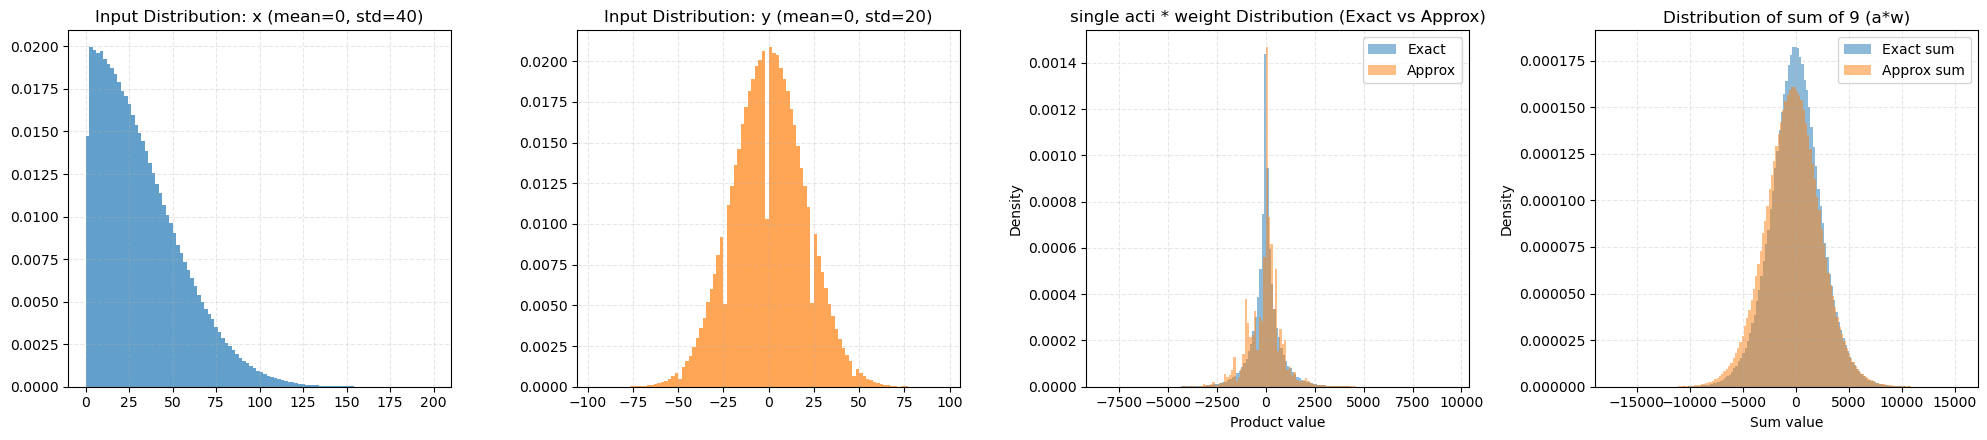

In [18]:
####################
## COMPARE RESULT ##
####################
# print("==== Error statistics ====")
# print(f"Mean error        : {error.mean():.4f}")
# print(f"Mean |error|      : {np.abs(error).mean():.4f}")
# print(f"RMSE              : {np.sqrt((error**2).mean()):.4f}")
# print(f"Max |error|       : {np.abs(error).max()}")
# print(f"Std of exact_out  : {exact_out.std():.4f}")
# print(f"Std of approx_out : {approx_out.std():.4f}")
plt.figure(figsize=(20, 4.5))

plt.subplot(1, 4, 1)
plt.hist(x_int, bins=100, alpha=0.7, color='C0', density=True)
plt.title('Input Distribution: x (mean=0, std=40)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplot(1, 4, 2)
plt.hist(y_int, bins=100, alpha=0.7, color='C1', density=True)
plt.title('Input Distribution: y (mean=0, std=20)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplot(1, 4, 3)
plt.hist(exact_out,  bins=150, alpha=0.5, density=True, label='Exact')
plt.hist(approx_out, bins=150, alpha=0.5, density=True, label='Approx')
plt.title('single acti * weight Distribution (Exact vs Approx)')
plt.xlabel('Product value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplot(1, 4, 4)
plt.hist(exact_sum,  bins=150, alpha=0.5, density=True, label='Exact sum')
plt.hist(approx_sum, bins=150, alpha=0.5, density=True, label='Approx sum')
plt.title('Distribution of sum of 9 (a*w)')
plt.xlabel('Sum value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()